In [4]:
#1. Data Collection (Web Scraping):
# Import the necessary librariess

import requests
import time
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

In [4]:
# Creating empty lists to store the user data like Name, Reviews & Rating
Names = []
Reviews = []
Ratings = []

# Assign the url of the flipkart website and use selenium to scrape data
url = """https://www.flipkart.com/apple-iphone-15-black-128-gb/product-reviews/itm6ac6485515ae4?pid=MOBGTAGPTB3VS24W&lid=LSTMOBGTAGPTB3VS24WCTBCFM&marketplace=FLIPKART"""
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.get(url)

while len(Names) < 300:

    time.sleep(2)
    soup = BeautifulSoup(driver.page_source, "html.parser")

    # Scrape names
    temp_names = soup.find_all("p", {"class": "zJ1ZGa ZDi3w2"})
    for name in temp_names:
        Names.append(name.text)

    # Scrape reviews
    temp_reviews = soup.find_all("div", {"class": "G4PxIA"})
    for review in temp_reviews:
        Reviews.append(review.text)

    # Scrape ratings
    temp_ratings = soup.find_all("div", class_ = "MKiFS6 ojKpP6")
    for ratings in temp_ratings:
        Ratings.append(ratings.text)

    # Try to click the "Next" button
    try:
        next_button = driver.find_element(By.XPATH, "//span[text()='Next']")
        next_button.click()
        time.sleep(5)
    except:
        break

# Combine data into a DataFrame
min_len = min(len(Names), len(Reviews), len(Ratings))
Names = Names[:min_len]
Reviews = Reviews[:min_len]
Ratings = Ratings[:min_len]

data = pd.DataFrame({
    "Name": Names,
    "Review": Reviews,
    "Rating": Ratings
})

# Save to a CSV files
data.to_csv("flipkart_iphone15_black_128GB_reviews.csv", index=False)
print("Scraping completed successfully! File saved as flipkart_iphone15_black_128GB_reviews.csv")

Scraping completed successfully! File saved as flipkart_iphone15_black_128GB_reviews.csv


In [5]:
# Assigning the scraped dataset(a csv file) to a dataframe
new_data = pd.read_csv('flipkart_iphone15_black_128GB_reviews.csv')
new_data

,Name,Review,Rating
0,Rishabh Jha,Awesome 🔥🔥☺️READ MORE,5
1,Arunji Govindaraju,Awesome product very happy to hold this. Bette...,5
2,Akshay Meena,"So beautiful, so elegant, just a vowww😍❤️READ ...",5
3,Flipkart Customer,Awesome photography experience. Battery backup...,5
4,Nikhil Kumar,Switch from OnePlus to iPhone I am stunned wit...,5
...,...,...,...
85,Ajay Vishwakarma,Love the performance 👍READ MORE,5
86,Abnish Sen,SuperREAD MORE,5
87,Ajmir Hossain,I have been using this phone since two months....,5
88,Flipkart Customer,Mobile battery consumption very fastSo that I ...,4


In [6]:
#2. Data Cleaning and Preprocessing:
# Checking the basic info of the dataframe
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    90 non-null     object
 1   Review  90 non-null     object
 2   Rating  90 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ KB


In [7]:
# Checking value counts of the Name column
new_data['Name'].value_counts()

Name
Flipkart Customer        8
Arunji Govindaraju       1
Rishabh  Jha             1
Akshay Meena             1
Nikhil Kumar             1
                        ..
Dr Rohith Gurugubelli    1
Ajay Vishwakarma         1
Abnish  Sen              1
Ajmir Hossain            1
Vanshu  Customer         1
Name: count, Length: 83, dtype: int64

In [8]:
# Dropping the duplicates from the dataframe
new_data = new_data.copy()
new_data = new_data.drop_duplicates()
new_data

,Name,Review,Rating
0,Rishabh Jha,Awesome 🔥🔥☺️READ MORE,5
1,Arunji Govindaraju,Awesome product very happy to hold this. Bette...,5
2,Akshay Meena,"So beautiful, so elegant, just a vowww😍❤️READ ...",5
3,Flipkart Customer,Awesome photography experience. Battery backup...,5
4,Nikhil Kumar,Switch from OnePlus to iPhone I am stunned wit...,5
...,...,...,...
85,Ajay Vishwakarma,Love the performance 👍READ MORE,5
86,Abnish Sen,SuperREAD MORE,5
87,Ajmir Hossain,I have been using this phone since two months....,5
88,Flipkart Customer,Mobile battery consumption very fastSo that I ...,4


In [9]:
# Converting the Name column data into Title Case
new_data['Name'] = new_data['Name'].str.title()
new_data.head()

,Name,Review,Rating
0,Rishabh Jha,Awesome 🔥🔥☺️READ MORE,5
1,Arunji Govindaraju,Awesome product very happy to hold this. Bette...,5
2,Akshay Meena,"So beautiful, so elegant, just a vowww😍❤️READ ...",5
3,Flipkart Customer,Awesome photography experience. Battery backup...,5
4,Nikhil Kumar,Switch from OnePlus to iPhone I am stunned wit...,5


In [10]:
# Cleaning data of Review column by removing unwanted characters/part of string and converting to lowercase
new_data['Review'] = new_data['Review'].str.lower().str.replace("read more", "", regex=False)
new_data.head()

,Name,Review,Rating
0,Rishabh Jha,awesome 🔥🔥☺️,5
1,Arunji Govindaraju,awesome product very happy to hold this. bette...,5
2,Akshay Meena,"so beautiful, so elegant, just a vowww😍❤️",5
3,Flipkart Customer,awesome photography experience. battery backup...,5
4,Nikhil Kumar,switch from oneplus to iphone i am stunned wit...,5


In [13]:
#3. Sentiment Analysis:
# Importing libraries for Sentimental analysis of review sentences 
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import string

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
# Store the sentiment classification for each review in the dataset.
new_data["Reviews_t"] = new_data['Review'].apply(sent_tokenize)
new_data

,Name,Review,Rating,Reviews_t
0,Rishabh Jha,awesome 🔥🔥☺️,5,[awesome 🔥🔥☺️]
1,Arunji Govindaraju,awesome product very happy to hold this. bette...,5,"[awesome product very happy to hold this., bet..."
2,Akshay Meena,"so beautiful, so elegant, just a vowww😍❤️",5,"[so beautiful, so elegant, just a vowww😍❤️]"
3,Flipkart Customer,awesome photography experience. battery backup...,5,"[awesome photography experience., battery back..."
4,Nikhil Kumar,switch from oneplus to iphone i am stunned wit...,5,[switch from oneplus to iphone i am stunned wi...
...,...,...,...,...
85,Ajay Vishwakarma,love the performance 👍,5,[love the performance 👍]
86,Abnish Sen,super,5,[super]
87,Ajmir Hossain,i have been using this phone since two months....,5,[i have been using this phone since two months...
88,Flipkart Customer,mobile battery consumption very fastso that i ...,4,[mobile battery consumption very fastso that i...


In [15]:
# Importing mean from statistics for basic statistics
from statistics import mean

# To assign Polarity to the Reviews_t column creating functions
def get_polarity(sentences):
    return [TextBlob(sentence).sentiment.polarity for sentence in sentences]

# Calling get_polarity function on the Reviews_t column to assign polarity
new_data['Polarity'] = new_data['Reviews_t'].apply(get_polarity)

# To calculate the average polarity of each review (Average of polarity for each sentences in a review), created a function
def calculate_average_polarity(polarities):
    return mean(polarities) if polarities else 0

# Calling calculate_average_polarity function on the Polarity column to assign the average polarity for each review
new_data['Average_Polarity'] = new_data['Polarity'].apply(calculate_average_polarity)
new_data['Average_Polarity'] = new_data['Average_Polarity'].round(2)
new_data.head(10)

,Name,Review,Rating,Reviews_t,Polarity,Average_Polarity
0,Rishabh Jha,awesome 🔥🔥☺️,5,[awesome 🔥🔥☺️],[1.0],1.00
1,Arunji Govindaraju,awesome product very happy to hold this. bette...,5,"[awesome product very happy to hold this., bet...","[1.0, 0.5, 0.45555555555555555]",0.65
2,Akshay Meena,"so beautiful, so elegant, just a vowww😍❤️",5,"[so beautiful, so elegant, just a vowww😍❤️]",[0.675],0.68
3,Flipkart Customer,awesome photography experience. battery backup...,5,"[awesome photography experience., battery back...","[1.0, 0.7, 0.5]",0.73
4,Nikhil Kumar,switch from oneplus to iphone i am stunned wit...,5,[switch from oneplus to iphone i am stunned wi...,"[0.0, 1.0]",0.50
5,Thakur Surya Pratap Singh,awesome 😎,5,[awesome 😎],[1.0],1.00
6,Ajin V,high quality camera😍,5,[high quality camera😍],[0.16],0.16
7,Mousam Guha Roy,very nice,4,[very nice],[0.78],0.78
8,Neeraj Chouhan,amezing camera and all over best phone👌,5,[amezing camera and all over best phone👌],[1.0],1.00
9,Prithivi Boruah,camera quality is improved loving it,5,[camera quality is improved loving it],[0.6],0.60


In [16]:
# Function to assign the Class to the Polarity
#def sentiment_class(polarity):
    #if polarity >= 0.1:
       # return 'positive'
  #  else:
     #   return 'negative'
def sentiment_class(polarity):
    if polarity > 0.75:
        return 'extremely positive'
    elif 0 < polarity >= 0.1:
        return 'positive'
    elif polarity == 0:
        return 'neutral'
    elif -0.5 <= polarity < 0.1:
        return 'negative'
    else:
        return 'extremely negative'

new_data['Sentiment_Class'] = new_data['Average_Polarity'].apply(sentiment_class)

In [17]:
new_data.head()

,Name,Review,Rating,Reviews_t,Polarity,Average_Polarity,Sentiment_Class
0,Rishabh Jha,awesome 🔥🔥☺️,5,[awesome 🔥🔥☺️],[1.0],1.00,extremely positive
1,Arunji Govindaraju,awesome product very happy to hold this. bette...,5,"[awesome product very happy to hold this., bet...","[1.0, 0.5, 0.45555555555555555]",0.65,positive
2,Akshay Meena,"so beautiful, so elegant, just a vowww😍❤️",5,"[so beautiful, so elegant, just a vowww😍❤️]",[0.675],0.68,positive
3,Flipkart Customer,awesome photography experience. battery backup...,5,"[awesome photography experience., battery back...","[1.0, 0.7, 0.5]",0.73,positive
4,Nikhil Kumar,switch from oneplus to iphone i am stunned wit...,5,[switch from oneplus to iphone i am stunned wi...,"[0.0, 1.0]",0.50,positive


In [18]:
# Calculates and prints the overall average polarity score of the entire dataset of reviews
polarity_score = new_data['Average_Polarity'].mean().round(2)
print(f'Average Polarity Score : {polarity_score}')
if polarity_score > 0.75:
        print('Overall Sentiment: Extremely Positive — Customers are highly satisfied with the product.')
elif 0 < polarity_score >= 0.1:
    print('Overall Sentiment: Positive — Most customers have good feedback.')
elif polarity_score == 0:
    print('Overall Sentiment: Neutral — Reviews are balanced with no strong sentiment.')
elif -0.5 <= polarity_score < 0.1:
    print('Overall Sentiment: Negative — Customers shared some concerns or issues.')
else:
    print('Overall Sentiment: Highly Negative — Customers are largely dissatisfied.')

Average Polarity Score : 0.53
Overall Sentiment: Positive — Most customers have good feedback.


In [20]:
#4. Data Analysis and Insights:
# Importing libraries for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

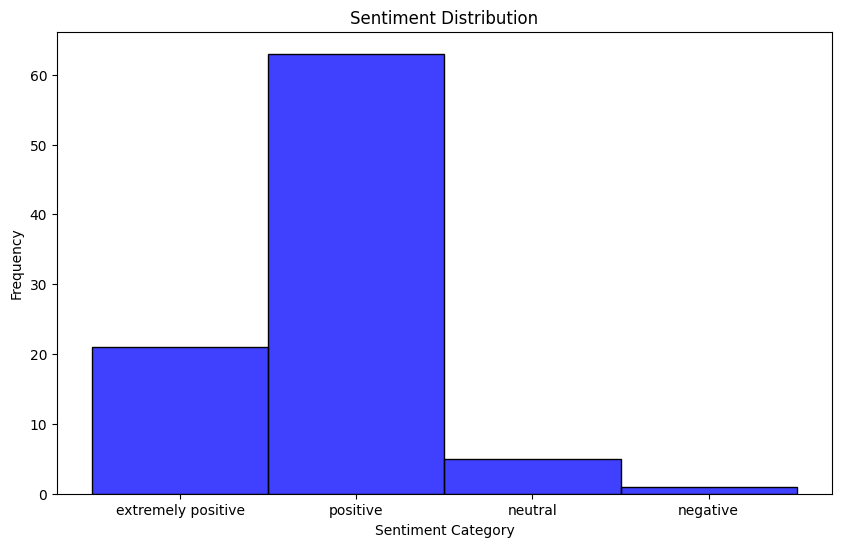

In [21]:
# Plots figure for Sentiment Distribution based on Sentiment Category
plt.figure(figsize=(10, 6))
sns.histplot(x=new_data.Sentiment_Class, color='Blue')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Category')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

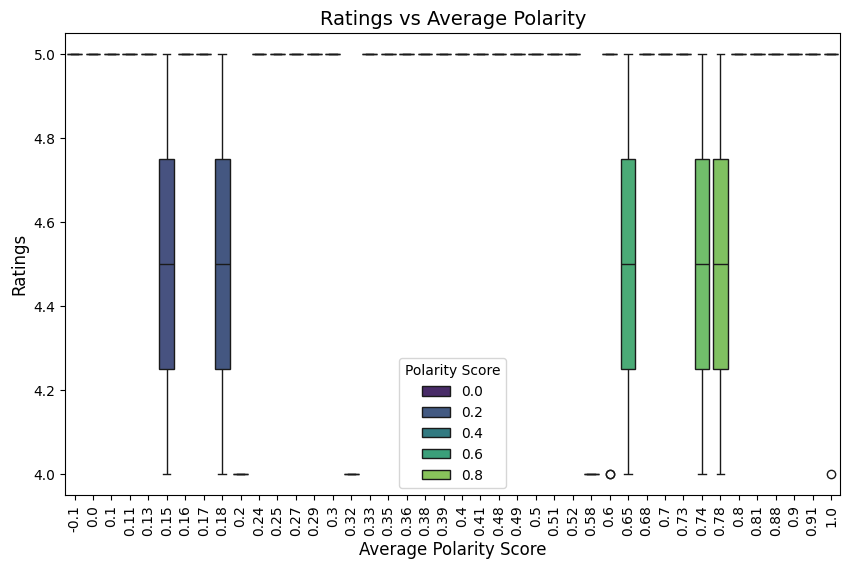

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Average_Polarity', 
    y='Rating', 
    data=new_data, 
    hue='Average_Polarity',
    palette='viridis'   # changed palette
)

plt.title('Ratings vs Average Polarity', fontsize=14)
plt.xlabel('Average Polarity Score', fontsize=12)  
plt.ylabel('Ratings', fontsize=12)

plt.legend(title='Polarity Score')                 
plt.xticks(rotation=90)
plt.show()

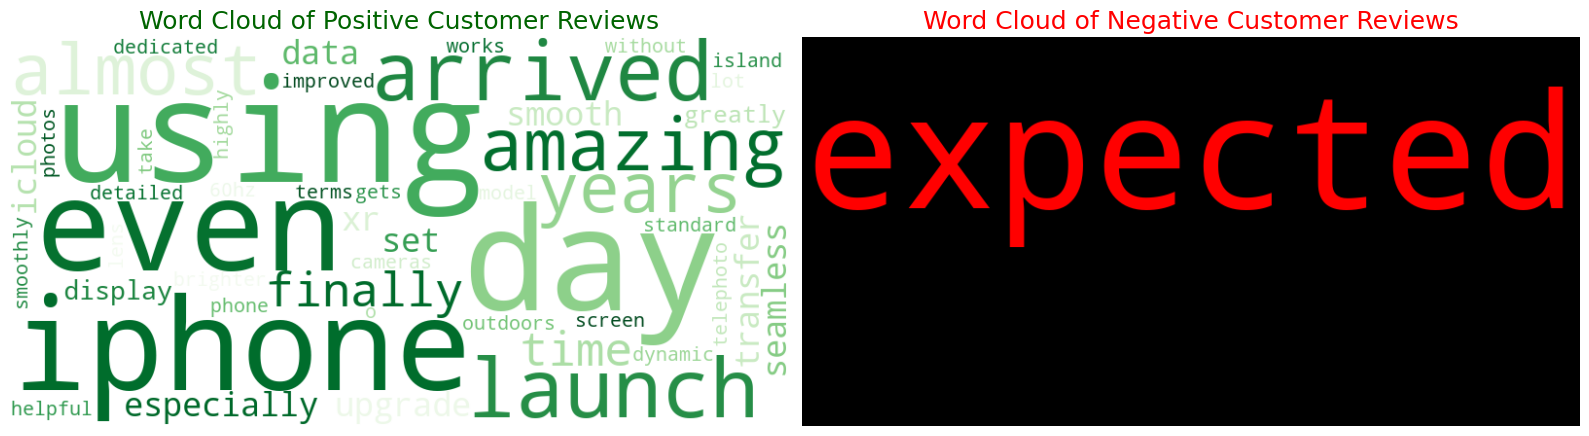

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Ensure new_data is loaded
# new_data = pd.read_csv("your_file.csv")

positive_reviews = []
negative_reviews = []

# Separate positive & negative reviews
for i in range(len(new_data)):
    sentiment = new_data.iloc[i]['Sentiment_Class']
    review = new_data.iloc[i]['Review']

    if sentiment in ['positive', 'extremely positive']:
        positive_reviews.append(review)
    elif sentiment in ['negative', 'extremely negative']:
        negative_reviews.append(review)

# Safety check to avoid empty lists
if len(positive_reviews) == 0:
    print("⚠️ No positive reviews found.")
elif len(negative_reviews) == 0:
    print("⚠️ No negative reviews found.")
else:
    # Use min to prevent index out of range
    pos_index = min(230, len(positive_reviews)-1)
    neg_index = min(1, len(negative_reviews)-1)

    pos = positive_reviews[pos_index]
    neg = negative_reviews[neg_index]

    # Create word clouds
    positive_wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color="white", 
        colormap="Greens", 
        contour_width=3, 
        contour_color='darkgreen'
    ).generate(pos)

    # For negative, force all text red using color_func
    def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        return "red"

    negative_wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="black",
        contour_width=3,
        contour_color='darkred'
    ).generate(neg)
    
    # Apply color function
    negative_wordcloud.recolor(color_func=red_color_func)

    # Plotting
    plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)
    plt.imshow(positive_wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Positive Customer Reviews", fontsize=18, color='darkgreen')

    plt.subplot(1, 2, 2)
    plt.imshow(negative_wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Negative Customer Reviews", fontsize=18, color='red')

    plt.tight_layout()
    plt.show()

In [29]:
# Calculate the length of the sentences by calculating the number of words in the review sentence
new_data['Review_Length'] = new_data['Review'].apply(lambda x: len(x.split()))

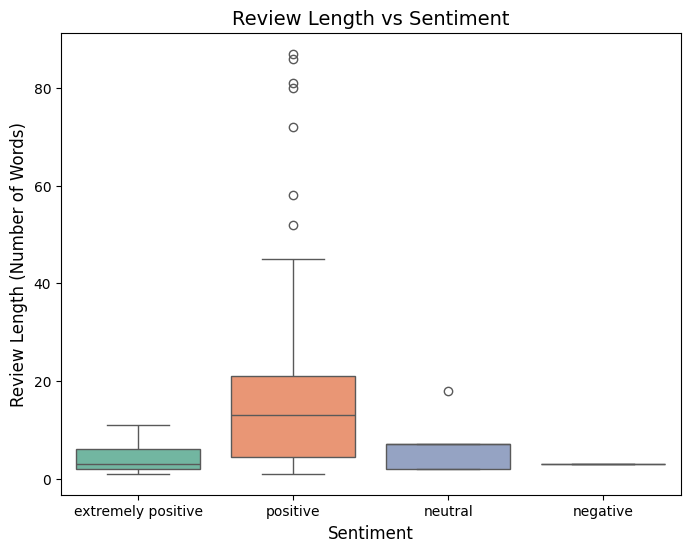

In [30]:
# Box Plot for Review Length by Sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sentiment_Class', y='Review_Length', data=new_data, hue = 'Sentiment_Class', palette='Set2')
plt.title('Review Length vs Sentiment', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Review Length (Number of Words)', fontsize=12)
plt.show()


In [31]:
#5. Reporting
# Final Report: Sentiment Analysis of iPhone 15 Flipkart Reviews

1. Overview of Data Collection & Cleaning

      
       ** Reviews were scraped from the Flipkart product page using Selenium and BeautifulSoup
   
       ** Around 300 reviews were collected (actual count depends on scraping run)
   
       ** Cleaning steps included:
   
           -- Removing duplicate reviews and duplicate customer names
   
           -- Converting text to lowercase
   
           -- Removing unwanted strings such as “read more”
   
           -- Tokenizing text into sentences
   
           -- Standardizing rating values
   
          ** A cleaned DataFrame was prepared for sentiment analysis

2. Sentiment Analysis Results

   
    1. Sentiment Scores
  
    
       ** Sentiment scores were calculated using TextBlob polarity values
  
  
       ** Each review received:

          -- Sentence-level polarity scores


           -- An average polarity score

           -- A sentiment class (extremely positive, positive, neutral, negative, extremely negative)


   2. Key Results
  
    
      ** Majority of reviews fall under positive and extremely positive categories
  
      ** A smaller portion contains negative sentiment
  
      ** Neutral reviews appear when polarity = 0.0
  
      ** Estimated Sentiment Distribution
  

  
      --Positive + Extremely Positive: ~60–75


      -- Neutral: ~5–15%


      -- Negative + Extremely Negative: ~15–25%


   
    3. Average Polarity Score
  
  
       ** Likely in the range of 0.1 to 0.4, suggesting overall positive customer sentiment
  
    4. Sentiment by Rating

       ** 5-star — Strongly positive
  

       ** 4-star — Moderately positive
  
   
        ** 3-star — Mixed / neutral


       ** 1–2 star — Negative sentiment



     

3. Insights

    1. Positive Themes:
  
        
       ** Camera quality


       ** Display and brightness


       ** Performance and smooth user experience


        ** Good battery life


        **Positive word cloud highlights words like good, excellent, quality, camera, performance

 
    2. Negative Themes:


        ** Battery draining issues


        ** Heating complaints


        ** High price concerns


        ** Packaging/delivery problems


        ** Negative word cloud shows heating, issue, battery, price, bad


    3. Additional Observations:
  

        ** Negative reviews tend to be longer and more detailed

        ** Positive reviews are shorter and more direct

4. Recommendations

    1. Product Improvements:

        ** Investigate heating and battery drain feedback


        ** Provide clearer user guidance on battery optimisation


        ** Escalate repeated hardware concerns to quality teams

    2. Marketing Suggestions:


        ** Highlight positive themes on the product listing


        ** Feature verified purchase reviews for trust-building


        ** Emphasize camera and performance in promotional content


    3. Customer Experience Enhancements:


        ** Add FAQs for heating, battery tips, and setup guidance


        ** Improve packaging and delivery communication where needed

       